Imports 

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)

Load Cleaned Data

In [4]:
df = pd.read_csv("D:/Entertainment_AI_Project/Notebooks/data/processed/movie_data_filtered.csv")
df.head()

,userId,movieId,rating,timestamp,title,genres,year,clean_title
0,1,296,5.0,2006-05-17 15:34:04,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,1994.0,Pulp Fiction
1,1,306,3.5,2006-05-17 12:26:57,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama,1994.0,Three Colors: Red (Trois couleurs: Rouge)
2,1,307,5.0,2006-05-17 12:27:08,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,1993.0,Three Colors: Blue (Trois couleurs: Bleu)
3,1,665,5.0,2006-05-17 15:13:40,Underground (1995),Comedy|Drama|War,1995.0,Underground
4,1,899,3.5,2006-05-17 12:21:50,Singin' in the Rain (1952),Comedy|Musical|Romance,1952.0,Singin' in the Rain


Basic Overview 

In [5]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

#Summary statistics
df.describe(include="all")

Shape: (24810483, 8)

Columns:
['userId', 'movieId', 'rating', 'timestamp', 'title', 'genres', 'year', 'clean_title']

Missing values:
userId             0
movieId            0
rating             0
timestamp          0
title              0
genres             0
year           10776
clean_title        0
dtype: int64

Data types:
userId           int64
movieId          int64
rating         float64
timestamp       object
title           object
genres          object
year           float64
clean_title     object
dtype: object


,userId,movieId,rating,timestamp,title,genres,year,clean_title
count,2.481048e+07,2.481048e+07,2.481048e+07,24810483,24810483,24810483,2.479971e+07,24810483
unique,NaN,NaN,NaN,19986587,18421,1203,NaN,17757
top,NaN,NaN,NaN,1996-03-01 00:00:00,Forrest Gump (1994),Drama,NaN,Forrest Gump
freq,NaN,NaN,NaN,619,81491,1736362,NaN,81491
mean,8.120692e+04,2.053185e+04,3.537668e+00,NaN,NaN,NaN,1.994300e+03,NaN
std,4.680803e+04,3.786092e+04,1.059172e+00,NaN,NaN,NaN,1.485283e+01,NaN
min,1.000000e+00,1.000000e+00,5.000000e-01,NaN,NaN,NaN,1.878000e+03,NaN
25%,4.051100e+04,1.196000e+03,3.000000e+00,NaN,NaN,NaN,1.990000e+03,NaN
50%,8.096500e+04,2.916000e+03,3.500000e+00,NaN,NaN,NaN,1.997000e+03,NaN
75%,1.215960e+05,8.361000e+03,4.000000e+00,NaN,NaN,NaN,2.003000e+03,NaN


EDA Starts 

1.Ratings Distributions

Because this helps answer:

Are users mostly giving high ratings or low ratings?

Is the dataset balanced or biased toward certain ratings?

Do users usually rate positively?

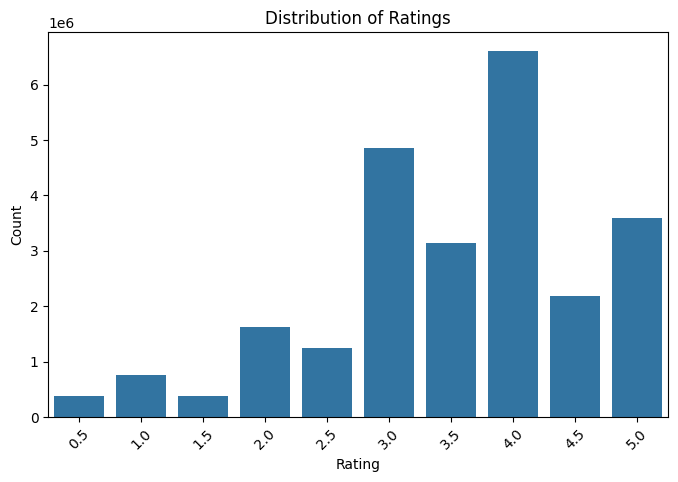

In [6]:
# Plot size is set to make the graph readable
plt.figure(figsize=(8,5))

# countplot shows how many times each rating value appears in the dataset
# This helps us understand the overall distribution of user ratings
sns.countplot(x="rating", data=df)

# Title and axis labels make the graph presentation-ready and easier to interpret
plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")

# Rotating x-axis labels slightly improves readability if labels are crowded
plt.xticks(rotation=45)

# Display the plot
plt.show()

2.Top 10 Most Rated Movies

This shows which movies are the most popular in terms of number of ratings, not average quality.

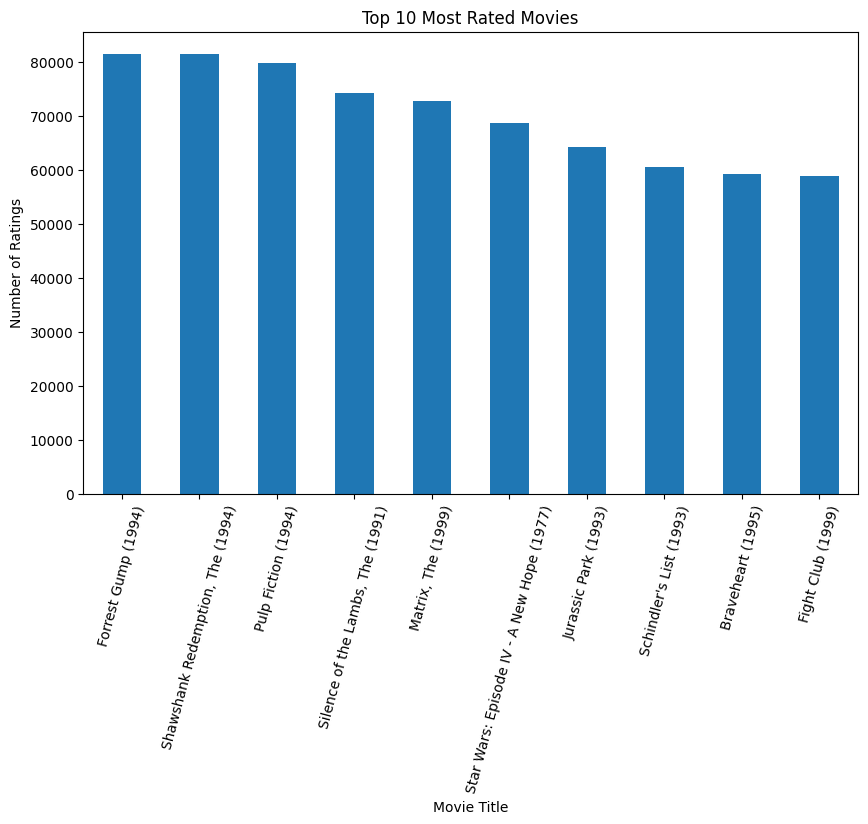

In [7]:
# Group by movie title and count how many ratings each movie received
# This tells us which movies are the most interacted with by users
most_rated = df.groupby("title")["rating"].count().sort_values(ascending=False).head(10)

most_rated


# Bar chart is useful here because we want to compare counts across top movies
most_rated.plot(kind="bar")

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Movie Title")
plt.ylabel("Number of Ratings")

# Movie names are long, so rotation improves readability
plt.xticks(rotation=75)

plt.show()

3.Top 10 Highest Rated Movies

This tells us which movies are best rated by users, while keeping the ranking fair by excluding movies with too few ratings.

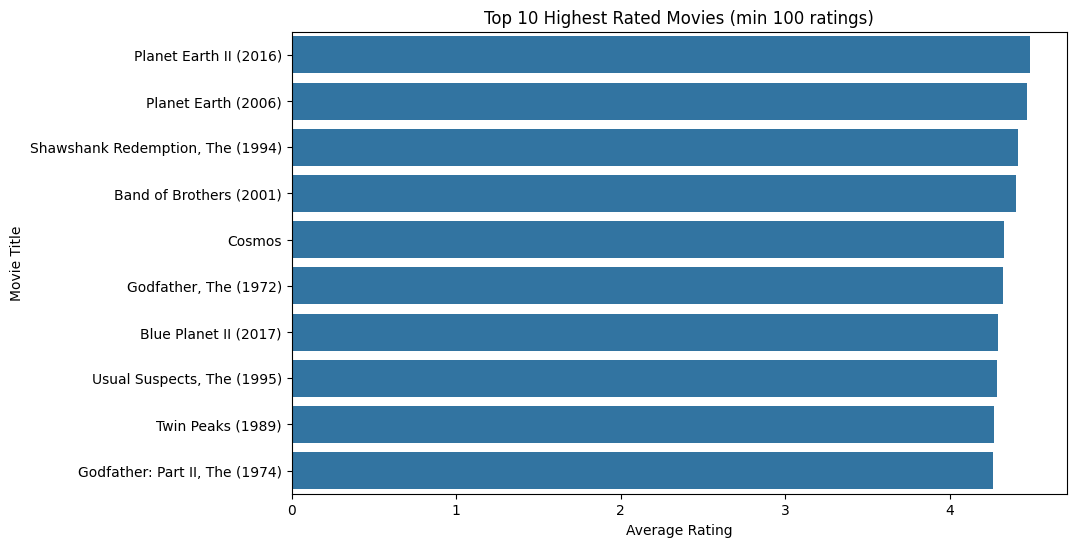

In [8]:
# We calculate both average rating and number of ratings
# because a movie with only 2 ratings should not be ranked above a movie with 500 ratings
movie_stats = df.groupby("title").agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
).reset_index()

# Apply a minimum rating count filter to make the ranking more reliable
top_rated = movie_stats[movie_stats["num_ratings"] >= 100].sort_values(
    by="avg_rating", ascending=False
).head(10)

top_rated

# Horizontal bar plot works better when movie titles are long
sns.barplot(data=top_rated, x="avg_rating", y="title")

plt.title("Top 10 Highest Rated Movies (min 100 ratings)")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.show()

4.Top 10 Most Active Users

This helps identify how user activity is distributed and whether there are highly active users in the dataset.

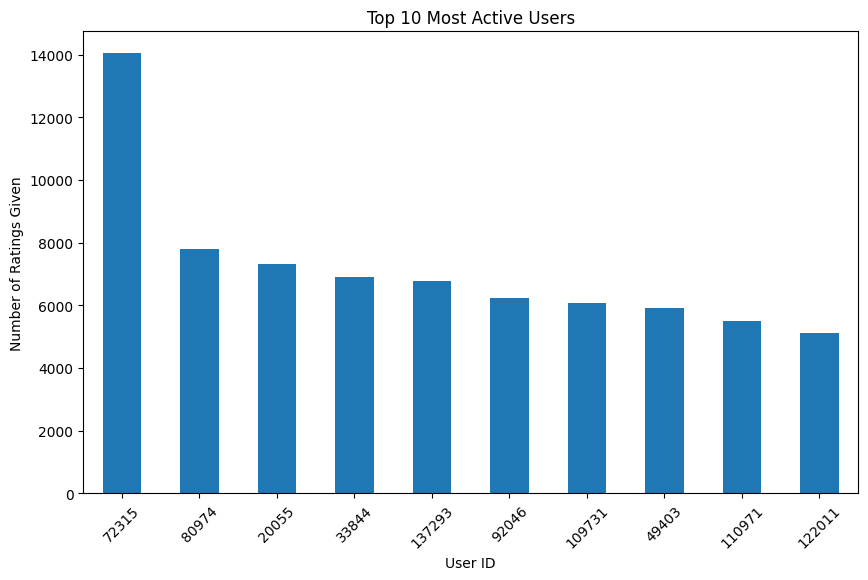

In [9]:
# Count how many ratings each user has given
# This helps us understand whether a few users are contributing a lot of the data
active_users = df["userId"].value_counts().head(10)

active_users

active_users.plot(kind="bar")

plt.title("Top 10 Most Active Users")
plt.xlabel("User ID")
plt.ylabel("Number of Ratings Given")
plt.xticks(rotation=45)

plt.show()

5.User Activity Distribution

This tells us whether:

most users rate only a few movies

or many users are highly active

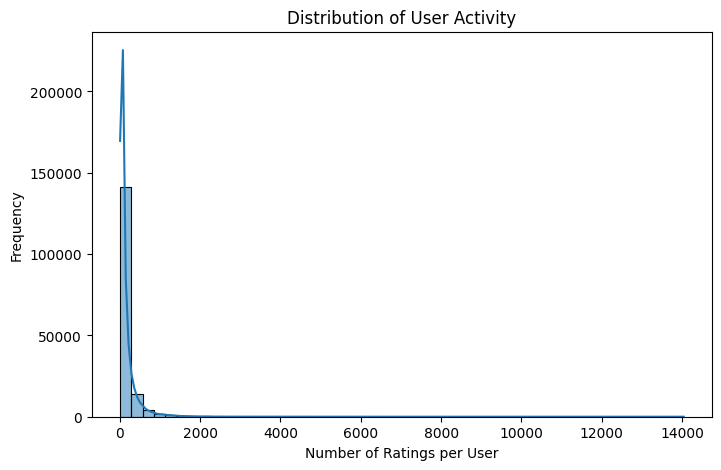

In [10]:
# value_counts gives the number of ratings per user
user_activity = df["userId"].value_counts()

plt.figure(figsize=(8,5))

# Histogram helps us see how user activity is spread across the dataset
sns.histplot(user_activity, bins=50, kde=True)

plt.title("Distribution of User Activity")
plt.xlabel("Number of Ratings per User")
plt.ylabel("Frequency")

plt.show()

6.Genre Distribution

Movies can belong to multiple genres, so we split them and count each genre separately to find the most common content categories.

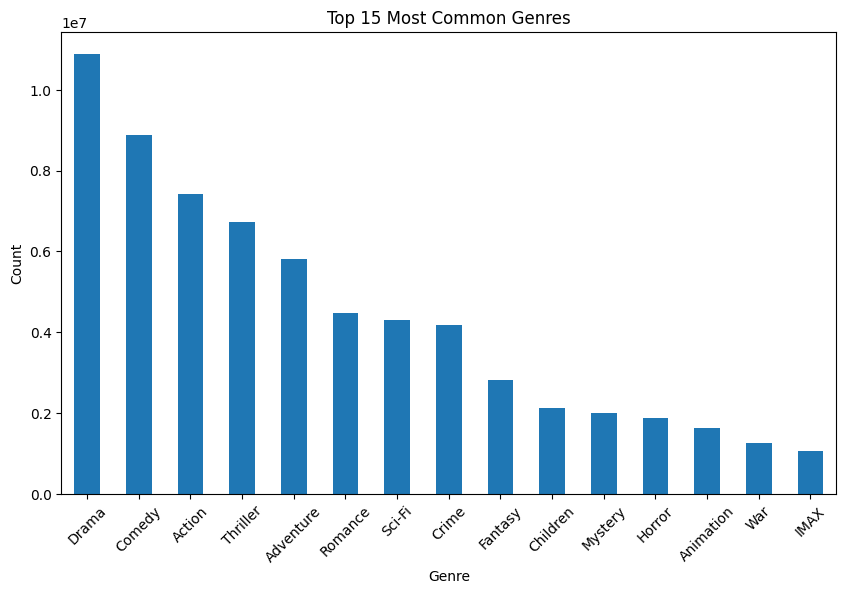

In [11]:
# Genres are stored together in one string separated by '|'
# explode converts multi-genre entries into separate rows for counting
genres_split = df["genres"].str.split("|").explode()

genre_counts = genres_split.value_counts().head(15)

genre_counts

genre_counts.plot(kind="bar")

plt.title("Top 15 Most Common Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.show()

7.Average Rating by Genre

This helps us see whether some genres are generally rated higher than others by users.

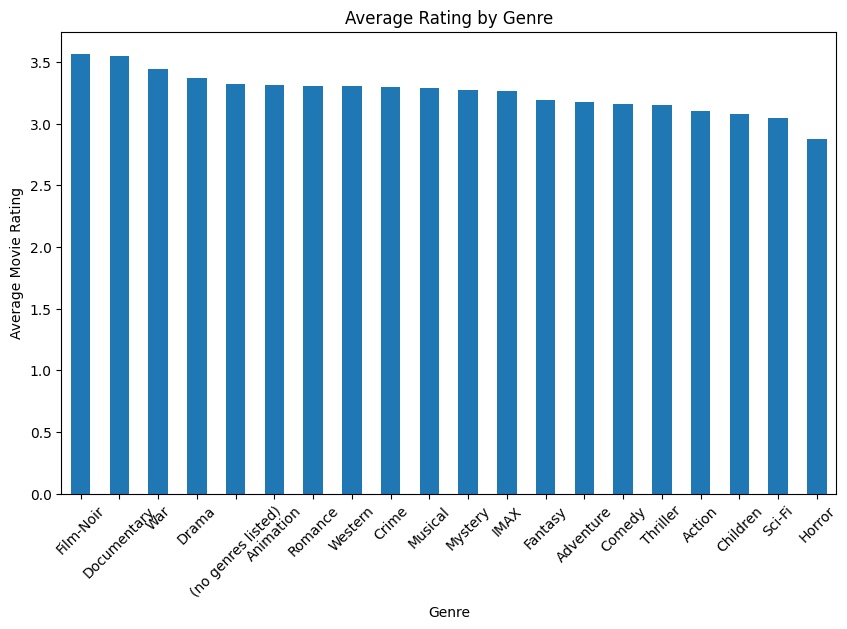

In [12]:
# First compute average rating per movie
# This reduces repeated rows because the same movie appears many times in the dataset
movie_avg = df.groupby(["movieId", "title", "genres"], as_index=False)["rating"].mean()
movie_avg.rename(columns={"rating": "avg_rating"}, inplace=True)

# Split genre strings into lists
movie_avg["genre"] = movie_avg["genres"].str.split("|")

# explode is now much safer because we are working on unique movies, not all rating rows
genre_movie_df = movie_avg.explode("genre")

# Compute average rating for each genre
genre_avg_rating = genre_movie_df.groupby("genre")["avg_rating"].mean().sort_values(ascending=False)

genre_avg_rating

genre_avg_rating.plot(kind="bar")

plt.title("Average Rating by Genre")
plt.xlabel("Genre")
plt.ylabel("Average Movie Rating")
plt.xticks(rotation=45)

plt.show()

8.Movies by Release Year

This helps identify whether the dataset is dominated by recent movies or contains strong representation from older years too.

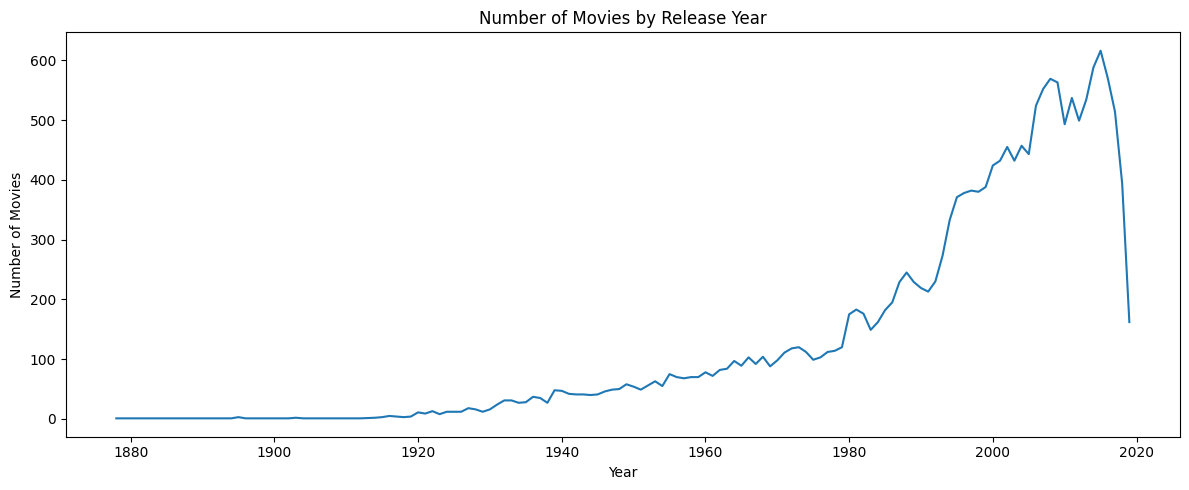

In [13]:
# Use only unique movies so each movie is counted once
movies_unique = df[["movieId", "title", "genres", "year"]].drop_duplicates()

# Count how many unique movies belong to each release year
year_counts = movies_unique["year"].value_counts().sort_index()

year_counts.tail(20)

plt.figure(figsize=(12,5))

# Line plot helps show how the number of released movies changes over time
year_counts.plot()

plt.title("Number of Movies by Release Year")
plt.xlabel("Year")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()

Recommendation System 

1.Popularity-Based Recommendation System

This reduces millions of rating rows into one row per movie with:

average rating

total number of ratings

In [14]:
# Group movie-wise and calculate average rating and total number of ratings
# This creates a compact movie-level summary from the large rating-level dataset
popularity_df = df.groupby(["movieId", "title"], as_index=False).agg(
    avg_rating=("rating", "mean"),
    num_ratings=("rating", "count")
)

popularity_df.head()

,movieId,title,avg_rating,num_ratings
0,1,Toy Story (1995),3.893708,57309
1,2,Jumanji (1995),3.251527,24228
2,3,Grumpier Old Men (1995),3.142028,11804
3,4,Waiting to Exhale (1995),2.853547,2523
4,5,Father of the Bride Part II (1995),3.058434,11714


In [15]:
# Keep only movies with enough ratings so recommendations are reliable
# A movie with 5.0 rating from only 2 users should not rank at the top
popular_movies = popularity_df[popularity_df["num_ratings"] >= 100].copy()

# Sort by highest average rating, and use number of ratings as tie-breaker
popular_movies = popular_movies.sort_values(
    by=["avg_rating", "num_ratings"],
    ascending=[False, False]
)

popular_movies.head(10)

,movieId,title,avg_rating,num_ratings
17333,171011,Planet Earth II (2016),4.483096,1124
16729,159817,Planet Earth (2006),4.464797,1747
312,318,"Shawshank Redemption, The (1994)",4.413576,81482
17298,170705,Band of Brothers (2001),4.398599,1356
17357,171495,Cosmos,4.326715,277
824,858,"Godfather, The (1972)",4.324336,52498
17697,179135,Blue Planet II (2017),4.289833,659
49,50,"Usual Suspects, The (1995)",4.284353,55366
18296,198185,Twin Peaks (1989),4.267361,288
1165,1221,"Godfather: Part II, The (1974)",4.261759,34188


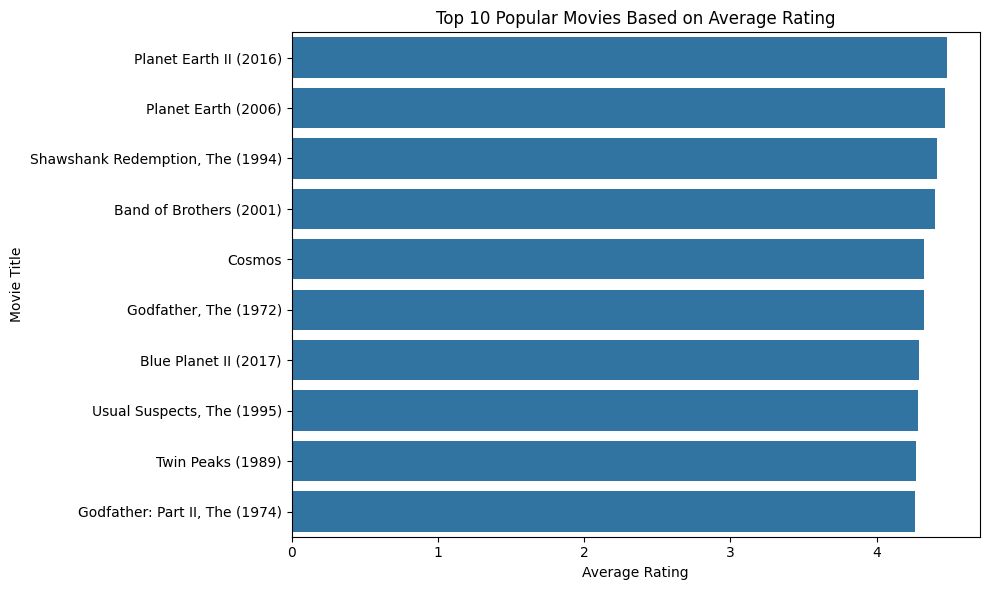

In [16]:
# Show the top 10 most recommendable popular movies
top_10_popular = popular_movies.head(10)
top_10_popular


# Visualize the top recommended popular movies
plt.figure(figsize=(10,6))
sns.barplot(data=top_10_popular, x="avg_rating", y="title")

plt.title("Top 10 Popular Movies Based on Average Rating")
plt.xlabel("Average Rating")
plt.ylabel("Movie Title")

plt.tight_layout()
plt.show()

In [17]:
def get_popular_movies(top_n=10, min_ratings=100):
    # Filter movies with enough ratings
    filtered = popularity_df[popularity_df["num_ratings"] >= min_ratings].copy()

    # Rank movies by rating first, then by number of ratings
    filtered = filtered.sort_values(
        by=["avg_rating", "num_ratings"],
        ascending=[False, False]
    )

    return filtered.head(top_n)

get_popular_movies()

,movieId,title,avg_rating,num_ratings
17333,171011,Planet Earth II (2016),4.483096,1124
16729,159817,Planet Earth (2006),4.464797,1747
312,318,"Shawshank Redemption, The (1994)",4.413576,81482
17298,170705,Band of Brothers (2001),4.398599,1356
17357,171495,Cosmos,4.326715,277
824,858,"Godfather, The (1972)",4.324336,52498
17697,179135,Blue Planet II (2017),4.289833,659
49,50,"Usual Suspects, The (1995)",4.284353,55366
18296,198185,Twin Peaks (1989),4.267361,288
1165,1221,"Godfather: Part II, The (1974)",4.261759,34188


2.Content-Based Recommendation System

1.Create movie-level unique dataset

We only need one row per movie for content-based recommendations.

In [19]:
# Keep only one row per movie
movies_unique = df[["movieId", "title", "genres"]].drop_duplicates()

movies_unique.head()

,movieId,title,genres
0,296,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
1,306,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama
2,307,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama
3,665,Underground (1995),Comedy|Drama|War
4,899,Singin' in the Rain (1952),Comedy|Musical|Romance


2.Convert genres into text features.

In [29]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Replace separator so CountVectorizer treats genres as separate tokens
movies_unique["genres_clean"] = movies_unique["genres"].str.replace("|", " ", regex=False)

movies_unique[["title", "genres", "genres_clean"]].head()

,title,genres,genres_clean
0,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,Comedy Crime Drama Thriller
1,Three Colors: Red (Trois couleurs: Rouge) (1994),Drama,Drama
2,Three Colors: Blue (Trois couleurs: Bleu) (1993),Drama,Drama
3,Underground (1995),Comedy|Drama|War,Comedy Drama War
4,Singin' in the Rain (1952),Comedy|Musical|Romance,Comedy Musical Romance


3.Vectorize genres + Compute similarity + Create title-to-index mapping

In [33]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

movies_unique = df[["movieId", "title", "genres"]].drop_duplicates().reset_index(drop=True)
movies_unique["genres_clean"] = movies_unique["genres"].str.replace("|", " ", regex=False)

cv = CountVectorizer()
genre_matrix = cv.fit_transform(movies_unique["genres_clean"])

movie_indices = pd.Series(movies_unique.index, index=movies_unique["title"]).drop_duplicates()

4. Recommendation Function 

In [34]:
def recommend_similar_movies(movie_title, top_n=10):
    # Check if movie exists
    if movie_title not in movie_indices:
        return f"Movie '{movie_title}' not found in dataset."

    # Get selected movie index
    idx = movie_indices[movie_title]

    # Compute similarity only for the selected movie, not the full dataset
    sim_scores = cosine_similarity(genre_matrix[idx], genre_matrix).flatten()

    # Get top similar movie indices
    similar_indices = sim_scores.argsort()[::-1][1:top_n+1]

    return movies_unique[["title", "genres"]].iloc[similar_indices]

In [35]:
recommend_similar_movies("Shawshank Redemption, The (1994)")

,title,genres
11468,"Enigma of Kaspar Hauser, The (a.k.a. Mystery o...",Crime|Drama
17793,November Criminals (2017),Crime|Drama
11205,Megan Is Missing (2011),Crime|Drama
1996,Outrage (Autoreiji) (2010),Crime|Drama
17068,"Deathmaker, The (Totmacher, Der) (1995)",Crime|Drama
2109,Carlito's Way (1993),Crime|Drama
6905,Suburra (2015),Crime|Drama
1896,Fireworks (Hana-bi) (1997),Crime|Drama
17961,"Humanité, L' (1999)",Crime|Drama
12402,Empire (2002),Crime|Drama


3. Collaborative Filtering Recommendation System

Create a smaller subset

In [1]:
# Count ratings per movie and per user
movie_rating_counts = df["title"].value_counts()
user_rating_counts = df["userId"].value_counts()

# Keep only popular movies and active users to reduce memory usage
selected_movies = movie_rating_counts[movie_rating_counts >= 500].index
selected_users = user_rating_counts[user_rating_counts >= 200].index

cf_df = df[
    (df["title"].isin(selected_movies)) &
    (df["userId"].isin(selected_users))
]

print("Collaborative filtering subset shape:", cf_df.shape)

NameError: name 'df' is not defined